# 02 EDA Starter

Project: **AI Support Operations SLA Breach and Priority Triage**

## Objective
Use EDA to understand SLA breach patterns and generate modelling hypotheses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load cleaned dataset first
path = Path("../01_Data/processed data/cleaned_support_sla_sample.csv")

# Fallback to raw dataset if cleaned file does not exist
if not path.exists():
    path = Path("../01_Data/raw data/sample_dataset.csv")

df = pd.read_csv(
    path,
    parse_dates=["submitted_at"],
    low_memory=False
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15000, 30)


,ticket_id,account_id,customer_segment,uk_region,support_channel,product_area,issue_category,priority_initial,submitted_at,day_of_week,...,assigned_agent,agent_experience_months,backlog_age_hours,first_response_minutes,reopened_last_90d,resolved_at,escalated_prior_to_resolution,resolution_hours,final_priority,sla_breached
0,TCK-202500000,ACC-93810,SMB,Wales,email,Reporting,service_outage,Critical,2025-09-06 18:51:00,Saturday,...,Amelia,6,13.11,62,0,2025-09-07 20:56:43,1,26.10,Critical,1
1,TCK-202500001,ACC-82357,SMB,East Midlands,web,Billing,data_quality,Medium,2026-02-27 08:29:00,Friday,...,Isla,30,8.35,289,0,2026-02-28 05:55:43,0,21.45,Medium,0
2,TCK-202500002,ACC-45093,SMB,East Midlands,web,Api Integration,access_request,Medium,2025-10-19 05:16:00,Sunday,...,Muhammad,19,11.28,215,0,2025-10-19 17:38:32,0,12.38,Medium,0
3,TCK-202500003,ACC-44973,Enterprise,Northern Ireland,web,Workflow Automation,how_to,Critical,2025-12-01 03:05:00,Monday,...,Isla,25,20.45,261,0,2025-12-01 10:42:39,1,7.63,Critical,1
4,TCK-202500004,ACC-26483,SMB,South West,email,Security,performance,High,2026-01-16 11:48:00,Friday,...,Harry,35,0.06,139,0,2026-01-16 23:11:33,0,11.39,High,0


## Target balance

sla_breached
1    9132
0    5868
Name: count, dtype: int64

sla_breached
1    0.6088
0    0.3912
Name: rate, dtype: float64

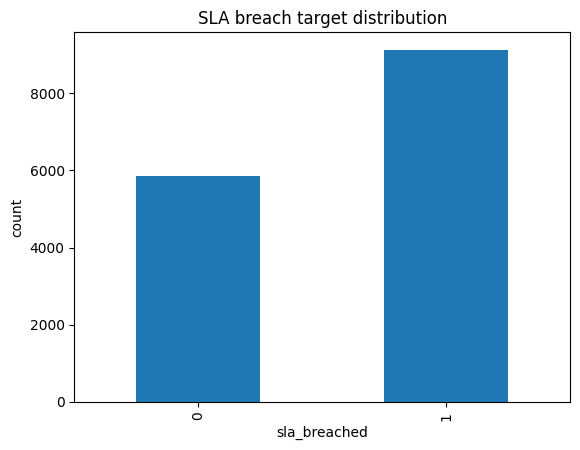

In [2]:
display(df["sla_breached"].value_counts())
display(df["sla_breached"].value_counts(normalize=True).rename("rate"))

ax = df["sla_breached"].value_counts().sort_index().plot(kind="bar")
ax.set_title("SLA breach target distribution")
ax.set_xlabel("sla_breached")
ax.set_ylabel("count")
plt.show()


## Target Variable Analysis

The target variable `sla_breached` indicates whether a support ticket breached its service-level agreement (SLA). Analysis shows that 9,132 tickets (60.88%) resulted in an SLA breach, while 5,868 tickets (39.12%) were resolved within the SLA target.

The distribution demonstrates a moderately balanced classification problem. Although breached tickets occur more frequently than non-breached tickets, both classes are well represented and suitable for supervised machine learning.

From a business perspective, the high proportion of SLA breaches suggests a significant operational challenge. A predictive model that can identify high-risk tickets before an SLA breach occurs could help support teams prioritize resources, improve response times, and reduce customer dissatisfaction.

Given the class distribution, standard classification algorithms can be applied without requiring aggressive resampling techniques. During model evaluation, metrics such as Precision, Recall, F1-Score, and ROC-AUC will be considered to assess predictive performance.


## Breach rate by operational segments

,count,mean
customer_segment,,
Enterprise,2754,0.889615
Public Sector,1008,0.878968
Mid-Market,4462,0.588301
SMB,6776,0.467975


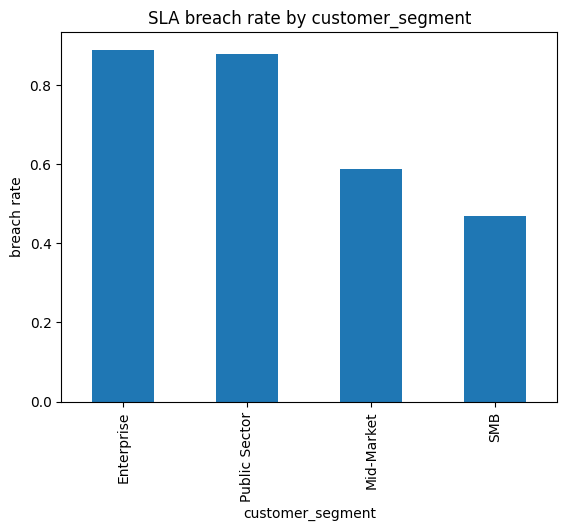

,count,mean
support_channel,,
web,4107,0.619917
phone,2437,0.609356
email,4570,0.605470
chat,2901,0.602551
partner portal,985,0.594924


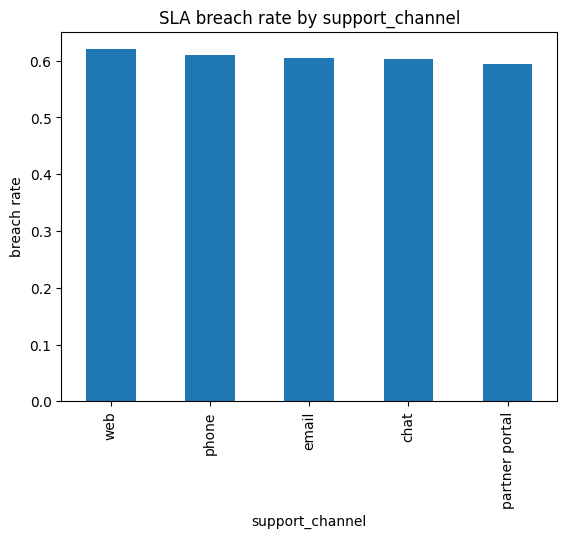

,count,mean
issue_category,,
service_outage,1338,0.917040
integration_failure,1535,0.897720
data_quality,1554,0.644144
performance,1478,0.627876
refund_request,913,0.614458
bug,2691,0.605351
billing_query,1708,0.516393
access_request,1537,0.418347
how_to,2246,0.393143


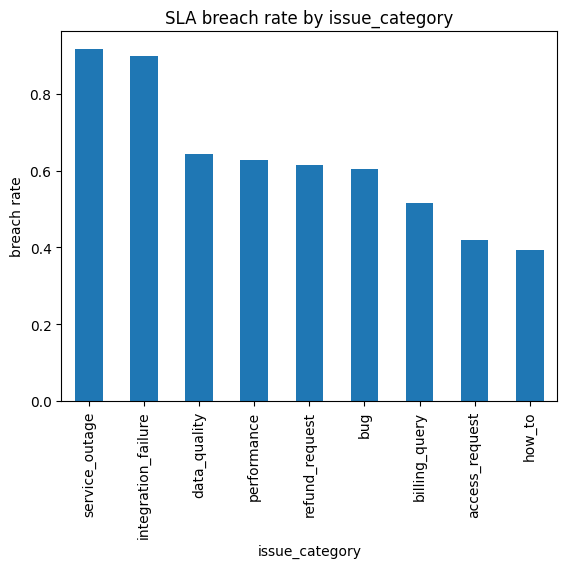

,count,mean
priority_initial,,
Critical,6963,0.978458
High,4640,0.498060
Medium,2698,0.002965
Low,699,0.000000


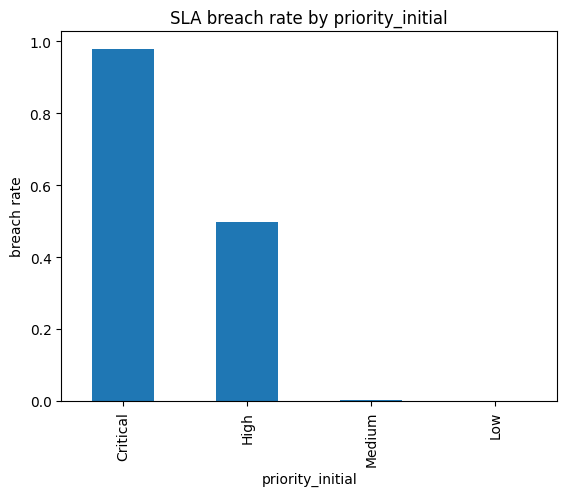

,count,mean
product_area,,
Billing,2269,0.625826
Payments,1737,0.620610
Mobile App,1500,0.618667
Reporting,1679,0.609887
Data Export,1218,0.609195
Account Access,1976,0.607287
Api Integration,1457,0.599176
Security,1175,0.599149
Workflow Automation,1989,0.584716


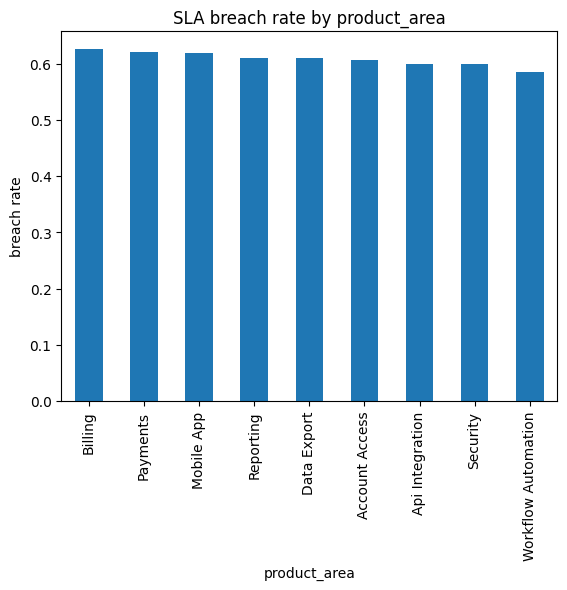

In [3]:
for col in ["customer_segment", "support_channel", "issue_category", "priority_initial", "product_area"]:
    summary = df.groupby(col, dropna=False)["sla_breached"].agg(["count", "mean"]).sort_values("mean", ascending=False)
    display(summary.head(15))
    summary["mean"].head(15).plot(kind="bar", title=f"SLA breach rate by {col}")
    plt.ylabel("breach rate")
    plt.show()


## Target Variable Analysis

The target variable `sla_breached` indicates whether a support ticket breached its service-level agreement (SLA). Analysis shows that 9,132 tickets (60.88%) resulted in an SLA breach, while 5,868 tickets (39.12%) were resolved within the SLA target.

The distribution demonstrates a moderately balanced classification problem. Although breached tickets occur more frequently than non-breached tickets, both classes are well represented and suitable for supervised machine learning.

From a business perspective, the high proportion of SLA breaches suggests a significant operational challenge. A predictive model that can identify high-risk tickets before an SLA breach occurs could help support teams prioritize resources, improve response times, and reduce customer dissatisfaction.

Given the class distribution, standard classification algorithms can be applied without requiring aggressive resampling techniques. During model evaluation, metrics such as Precision, Recall, F1-Score, and ROC-AUC will be considered to assess predictive performance.


## Numerical distributions and outliers

,count,mean,std,min,25%,50%,75%,max
contract_value_gbp,15000.0,35149.877380,97428.378369,618.17,8039.39250,15664.655,33581.840,5164231.50
previous_tickets_90d,15000.0,2.532200,3.002571,0.00,0.00000,2.000,4.000,26.00
avg_sentiment_score,15000.0,-0.011504,0.498620,-1.00,-0.36225,-0.009,0.341,1.00
message_length,15000.0,99.083200,13.777073,73.00,89.00000,97.000,107.000,161.00
agent_queue_length_at_submit,15000.0,33.486133,17.149723,0.00,21.00000,33.000,45.000,96.00
agent_experience_months,15000.0,19.999200,12.881904,1.00,10.00000,19.000,29.000,75.00
backlog_age_hours,15000.0,9.381934,16.064169,0.00,2.37000,5.740,11.690,479.82
first_response_minutes,15000.0,147.965600,82.520982,1.00,88.00000,146.000,204.000,487.00
resolution_hours,15000.0,25.673916,11.692520,0.30,18.37000,25.100,31.840,233.59


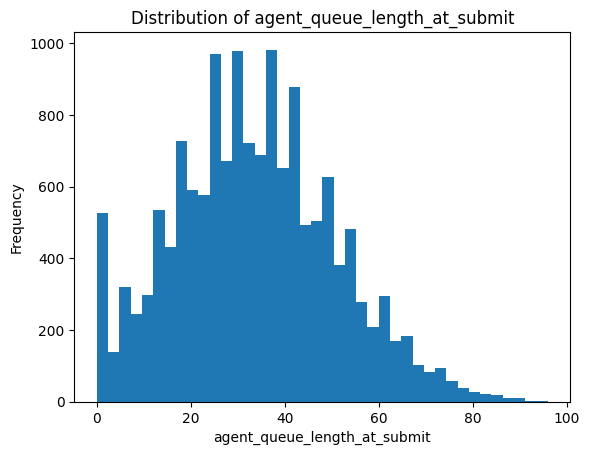

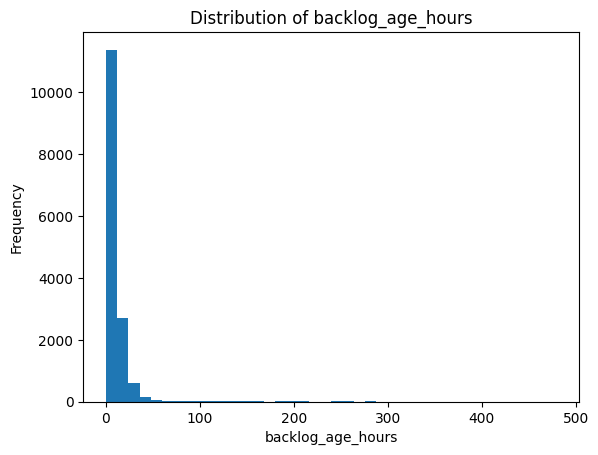

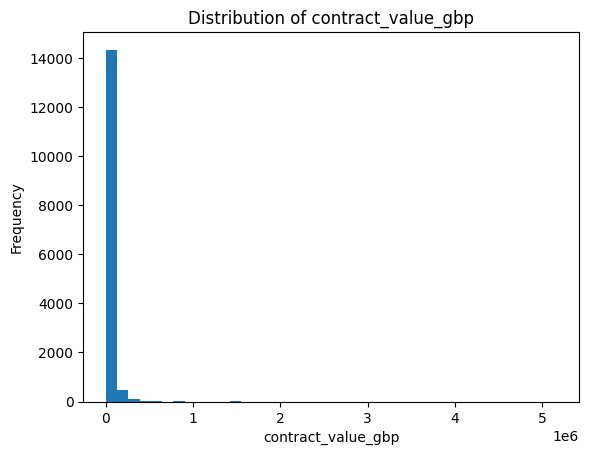

In [6]:
num_cols = ["contract_value_gbp", "previous_tickets_90d", "avg_sentiment_score", 
            "message_length", "agent_queue_length_at_submit", "agent_experience_months",
            "backlog_age_hours", "first_response_minutes", "resolution_hours"]

display(df[num_cols].describe().T)

for col in ["agent_queue_length_at_submit", "backlog_age_hours", "contract_value_gbp"]:
    df[col].plot(kind="hist", bins=40, title=f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()


## Numerical Feature Analysis

Descriptive analysis of numerical variables highlights several characteristics that may influence SLA breach outcomes.

The average customer contract value is £35,149; however, the maximum value exceeds £5.16 million, indicating a highly right-skewed distribution with a small number of very large enterprise accounts. This suggests that contract value may be an important factor when prioritising support resources.

Customers submitted an average of 2.53 previous tickets within the last 90 days, although some customers generated as many as 26 tickets. Higher ticket volumes may indicate recurring issues or complex support requirements.

Customer sentiment scores are centred around zero, with values ranging from -1 to 1. This variation may provide useful information regarding customer satisfaction and potential escalation risk.

Operational metrics show considerable variability. The average queue length at ticket submission was 33 tickets, while backlog age averaged 9.38 hours. Some tickets experienced backlog ages of almost 480 hours, indicating periods of substantial operational pressure.

The average first response time was approximately 148 minutes, with some tickets waiting over 8 hours before receiving an initial response. Delayed responses may contribute significantly to SLA breaches and customer dissatisfaction.

Overall, workload-related variables such as queue length, backlog age, response time, and previous ticket history appear likely to be strong predictors of SLA breach risk. Several variables exhibit right-skewed distributions and potential outliers; however, these observations appear operationally plausible and will be retained for modelling purposes.


## Time-based patterns

submitted_hour
0.0     0.584270
1.0     0.601709
2.0     0.612698
3.0     0.611475
4.0     0.599359
5.0     0.591185
6.0     0.589172
7.0     0.566942
8.0     0.562401
9.0     0.706362
10.0    0.673529
11.0    0.663808
12.0    0.559068
13.0    0.593407
14.0    0.683946
15.0    0.642140
16.0    0.694400
17.0    0.597264
18.0    0.585484
19.0    0.597338
20.0    0.583596
21.0    0.593220
22.0    0.539735
23.0    0.581433
Name: sla_breached, dtype: float64

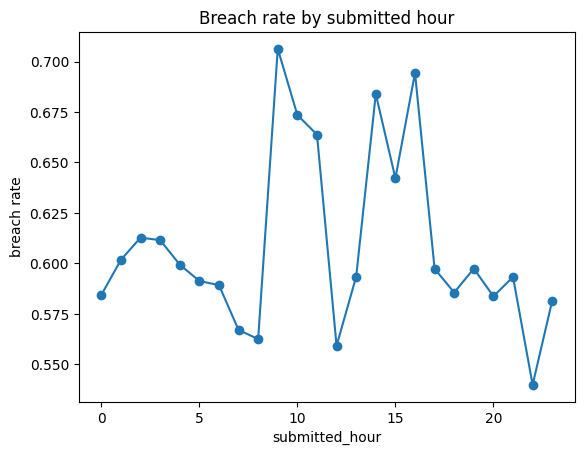

In [7]:
df["submitted_at"] = pd.to_datetime(df["submitted_at"], errors="coerce")
df["submitted_month"] = df["submitted_at"].dt.to_period("M").astype(str)
df["submitted_hour"] = df["submitted_at"].dt.hour

display(df.groupby("submitted_hour")["sla_breached"].mean().sort_index())
df.groupby("submitted_hour")["sla_breached"].mean().sort_index().plot(kind="line", marker="o", title="Breach rate by submitted hour")
plt.ylabel("breach rate")
plt.show()


## Temporal Analysis

The relationship between ticket submission time and SLA breach outcomes was examined by calculating breach rates for each hour of the day.

The analysis reveals noticeable variation in breach rates across different submission hours. Tickets submitted during peak business periods, particularly between 09:00–11:00 and 14:00–16:00, exhibit the highest breach rates, exceeding 65% in several cases. The highest observed breach rate occurs at 09:00, where approximately 70.6% of tickets breach their SLA target.

In contrast, tickets submitted during off-peak periods generally experience lower breach rates. This pattern suggests that operational workload, staffing levels, and ticket volume may influence SLA performance throughout the day.

These findings indicate that submission time could provide useful predictive information when developing an SLA breach prediction model. Time-based features such as submission hour, working hours, and peak-period indicators may therefore be valuable candidates for feature engineering in later stages of the project.


### Key Findings and Modelling Considerations

* SLA breaches are common within the dataset, with approximately 60.9% of support tickets failing to meet their SLA targets. This indicates a meaningful business problem and supports the need for predictive modelling.

* Customer segment is strongly associated with SLA outcomes. Enterprise and Public Sector customers exhibit substantially higher breach rates than SMB customers, suggesting that account complexity influences resolution performance.

* Issue category is one of the most informative variables. Service outage and integration failure tickets show exceptionally high breach rates, while "How To" and access request tickets are significantly less likely to breach SLA targets.

* Initial ticket priority appears to be highly predictive of SLA outcomes. Critical tickets experience very high breach rates, whereas Medium and Low priority tickets rarely breach SLA targets. This feature should be carefully evaluated during modelling.

* Operational workload metrics such as queue length, backlog age, and first response time are likely to be important predictors because they directly reflect support team capacity and ticket-processing delays.

* Submission time shows measurable variation in breach rates, with tickets submitted during peak business hours experiencing higher breach frequencies. Time-based features may therefore provide additional predictive value.

* Several variables (`resolved_at`, `resolution_hours`, `final_priority`, and `escalated_prior_to_resolution`) contain post-resolution information and represent potential target leakage. These features must be excluded from model training to ensure realistic performance estimates.
